# **Carga de datos**

Para este colab utilizare imágenes de retinografías en las que en unas hay una cantidad de glaucoma y en otras el ojo está sano. Primero voy a cargar las imágenes de la base de datos que se encuentra divida en 70% entrenamiento, 10% validación y un 20% de prueba.

In [2]:
import os

raiz = 'Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_normal_dir = os.path.join(train_dir, 'Normales')
train_glaucoma_dir = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_normal_dir = os.path.join(val_dir, 'Normales')
val_glaucoma_dir = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_normal_dir = os.path.join(test_dir, 'Normales')
test_glaucoma_dir = os.path.join(test_dir, 'Glaucomas')

In [3]:
print('train_dir:', len(os.listdir(train_normal_dir)), 'Normales,', len(os.listdir(train_glaucoma_dir)), 'Glaucoma')
print('val_dir:', len(os.listdir(val_normal_dir)), 'Normales,', len(os.listdir(val_glaucoma_dir)), 'Glaucoma')
print('test_dir:', len(os.listdir(test_normal_dir)), 'Normales,', len(os.listdir(test_glaucoma_dir)), 'Glaucoma')

print('Total de imágenes de entrenamiento:', len(os.listdir(train_normal_dir)) + len(os.listdir(train_glaucoma_dir)))
print('Total de imágenes de validación:', len(os.listdir(val_normal_dir)) + len(os.listdir(val_glaucoma_dir)))
print('Total de imágenes de prueba:', len(os.listdir(test_normal_dir)) + len(os.listdir(test_glaucoma_dir)))

train_dir: 219 Normales, 120 Glaucoma
val_dir: 31 Normales, 17 Glaucoma
test_dir: 63 Normales, 35 Glaucoma
Total de imágenes de entrenamiento: 339
Total de imágenes de validación: 48
Total de imágenes de prueba: 98


# **Data augmentation**

Antes de empezar a configurar la red neuronal, debemos realizar un preprocesado de las imagenes, para ello utilizare el módulo *tensorflow.preprocessing.image*

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(rescale=1./255)
val_generator = ImageDataGenerator(rescale=1./255)
test_generator = ImageDataGenerator(rescale=1./255)

train_data = train_generator.flow_from_directory(train_dir,
                                                 target_size=(150, 150),
                                                 class_mode='binary',
                                                 batch_size=10)

val_data = val_generator.flow_from_directory(val_dir,
                                             target_size=(150, 150),
                                             class_mode='binary',
                                             batch_size=10)

test_data = test_generator.flow_from_directory(test_dir,
                                               target_size=(150, 150),
                                               class_mode='binary',
                                               batch_size=10)

Found 339 images belonging to 2 classes.
Found 48 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


# **Importación del modelo de red neuronal**

Una vez ya cargado y preprocesado los datos, ahora voy a importar el modelo de red neurona **VGG19** de la base de datos de keras. Y aplico la técnica de *feature extractions* que consiste en no entrenar las capas convolucionales de la red y en agregar nuestro propio clasificador para adaptarlo a nuestras imágenes.

In [37]:
from tensorflow.keras.applications import VGG19

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

for layer in base_model.layers:
    layer.trainable = False

base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [38]:
# Agrego la capa densa de salida
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import Sequential

model = Sequential()

model.add(base_model)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 4, 4, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,122,049 (84.39 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

# **Entrenamiento del modelo**

Ahora voy a establecer los parámetros al modelo con el método fit() para que este sepa cómo tiene que entrenar. El modelo se basará en lo siguiente:

* Función de pérdida *binary_crossentropy*
* *accuracy* cómo métricas.
* *adam* cómo optimizador

In [39]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [40]:
batch_size = 10

steps_per_epoch = train_data.n // batch_size
validation_steps = val_data.n // batch_size

print(steps_per_epoch)
print(validation_steps)

33
4


In [42]:
model.fit(train_data,
          epochs=50,
          steps_per_epoch=steps_per_epoch,
          validation_steps=validation_steps,
          validation_data=val_data)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.6869 - loss: 0.5821 - val_accuracy: 0.5750 - val_loss: 0.7279
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.4000 - loss: 0.9077 - val_accuracy: 0.6250 - val_loss: 0.6683
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 482ms/step - accuracy: 0.7082 - loss: 0.5604 - val_accuracy: 0.5250 - val_loss: 0.7675
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5000 - loss: 0.7131 - val_accuracy: 0.6250 - val_loss: 0.6658
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 519ms/step - accuracy: 0.7781 - loss: 0.4890 - val_accuracy: 0.6000 - val_loss: 0.6840
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8000 - loss: 0.4724 - val_accuracy: 0.6500 - val_loss: 0.6625
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 528ms/step - accuracy: 0.7812 - loss: 0.4445 - val_accuracy: 0.6250 - val_loss: 0.6868
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 1.0000 - loss: 0.3519 - val_accuracy: 0.

In [43]:
loss, acc = model.evaluate(test_data)

print('Test accuracy:', acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - accuracy: 0.8469 - loss: 0.5101
Test accuracy: 0.8469387888908386


# **Comprobación de los datos**

Con el modelo ya entrenado, voy a mostrar algunas imágenes de nuestro conjunto de prueba para ver si está en lo correcto el modelo.

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


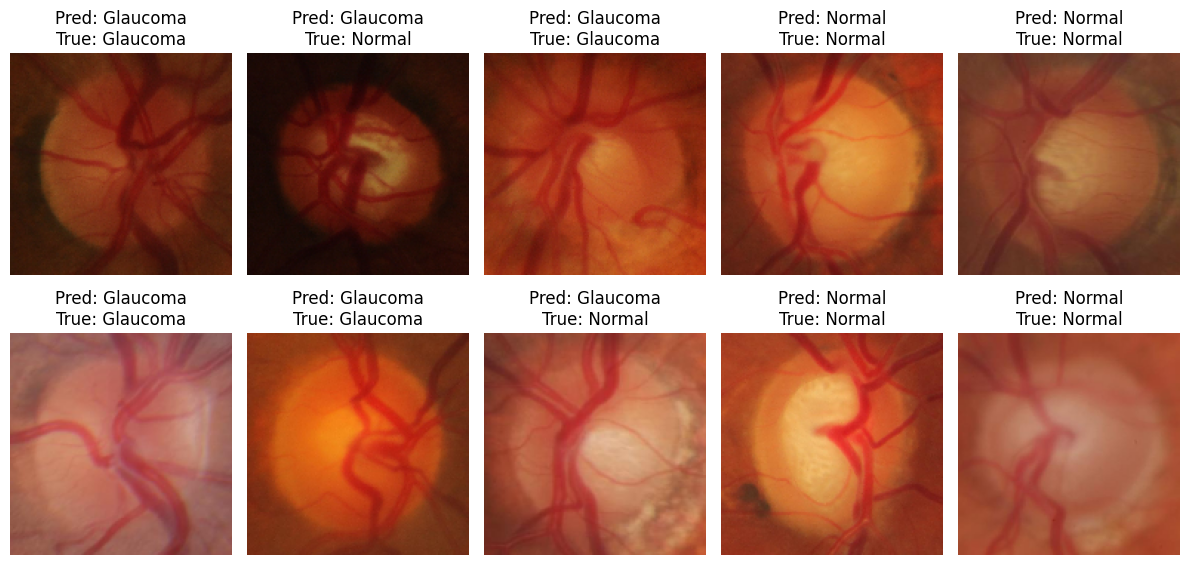

In [52]:
predictions = model.predict(test_data)

# Muestro las primeras imágenes de prueba con sus predicciones
import matplotlib.pyplot as plt
import numpy as np
test_data.reset()  # Reinicio el generador para obtener las imágenes desde el principio
images, labels = next(test_data)  # Obtengo un batch de imágenes y etiquetas
preds = model.predict(images)  # Obtengo las predicciones para el batch
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title(f'Pred: {"Glaucoma" if preds[i] > 0.5 else "Normal"}\nTrue: {"Glaucoma" if labels[i] == 1 else "Normal"}')
    plt.axis('off')
plt.tight_layout()
plt.show()